# 02. Feature Engineering — EDA 시사점 → 피처 설계

`01_EDA`의 결론을 피처 결정으로 옮긴다. 각 단계는 **결정 → 근거(데이터) → 결과** 순서로 정리한다.

| 단계 | 결정할 것 | 연결되는 EDA |
|---|---|---|
| 1 | 타깃 변환 (`log10(cycle_life)`) | Q1 왜도 · Q3 로그 선형성 |
| 2 | ΔQ(V) 비교 사이클 쌍 (i − j) | Q3 |
| 3 | 피처 후보 20 + 4개 구성, 결측 처리 | Q2 · Q4 · Q5 |
| 4 | 배치 간 안정성 (상관 부호, 분포 이동) | Q1 · Q4 배치 효과 |
| 5 | 다중공선성 제거 (VIF) | Q5 |
| 6 | 최종 피처 세트 저장 → `03_modeling` | — |

**학습/평가 분할 주의** : 원논문은 Batch 1·2의 84셀을 수명 범위가 고르게 섞이도록 학습 41 / 1차 테스트 43으로 나누었고, Batch 3(40셀)을 2차 테스트로 썼다. 이 과제는 **Batch 1 → Batch 2**로 나누므로 배치 간 차이를 논문보다 직접적으로 겪는다. 그래서 이 노트북은 모든 선택을 **Batch 1만 보고** 결정하고, Batch 2·3은 "선택이 배치를 넘어 유지되는지" 확인용으로만 쓴다.

In [ ]:
# 0. 환경 설정 — Drive에 올려둔 프로젝트 폴더에서 실행
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_DIR = '/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project'
    # src/ 가 바로 들어있는 폴더를 프로젝트 루트로 사용
    PROJECT_DIR = WORK_DIR if os.path.isdir(f'{WORK_DIR}/src') else f'{WORK_DIR}/ess-battery-project'
    assert os.path.isdir(f'{PROJECT_DIR}/src'), f'src 폴더를 찾지 못했습니다 : {PROJECT_DIR}'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'], check=False)
else:
    PROJECT_DIR = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print('PROJECT_DIR :', PROJECT_DIR, '| src 존재 :', os.path.isdir('src'))

Mounted at /content/drive
PROJECT_DIR : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project | src 존재 : True


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

from src.utils import Reporter, BATCHES, BCOLOR, PROCESSED_DIR
from src.preprocess import get_dataset, Q_CYCLES
from src.features import (build_feature_table, dq_curve, corr_by_batch, vif, usable_features, select_by_vif,
                          FEATURE_SETS, ALL_FEATS, DQ_FEATS, CURVE_FEATS, OTHER_FEATS, POLICY_FEATS)

R = Reporter('02_feature_engineering')
ds = get_dataset()            # 01_EDA에서 만든 파싱 캐시 + 같은 정제 규칙
meta = ds['meta']
R.log('셀 수 :', meta.groupby('batch').size().to_dict())

셀 수 : {'B1': 41, 'B2': 39, 'B3': 40}


## 1. 타깃 변환 — `log10(cycle_life)`
**근거** : Q1에서 수명 분포가 오른쪽으로 치우쳐 있고, Q3에서 ΔQ 분산과 수명은 **로그-로그**에서 선형이었다. 회귀 오차가 수명에 비례해 커지는 문제(장수명 셀 오차 과대)도 로그 변환으로 완화되고, 평가 지표인 MAPE(상대 오차)와도 성격이 맞는다.

In [ ]:
R.section('1. 타깃 변환')
for b in BATCHES + ['ALL']:
    s = meta if b == 'ALL' else meta[meta.batch == b]
    y = s.cycle_life
    R.log(f'  {b:3s}: skew raw={stats.skew(y):+.2f} → log={stats.skew(np.log10(y)):+.2f} | '
          f'Shapiro p raw={stats.shapiro(y).pvalue:.3g} → log={stats.shapiro(np.log10(y)).pvalue:.3g}')


1. 타깃 변환
  B1 : skew raw=+2.06 → log=+1.31 | Shapiro p raw=1.91e-07 → log=0.000232
  B2 : skew raw=+1.57 → log=+1.30 | Shapiro p raw=1.19e-07 → log=1.3e-06
  B3 : skew raw=+1.47 → log=+0.67 | Shapiro p raw=7.16e-05 → log=0.0307
  ALL: skew raw=+1.46 → log=+0.27 | Shapiro p raw=6.04e-09 → log=0.00115


## 2. ΔQ(V) 비교 사이클 쌍 선택
**결정** : ΔQ_{i−j}(V)의 (i, j)를 바꿔가며 `log Var(ΔQ)`와 `log life`의 상관을 계산하고, **Batch 1에서 강하면서 Batch 2에서도 유지되는** 쌍을 고른다.
논문 Fig. 5도 같은 분석을 했고 "i > 60 이후에는 성능이 거의 평탄하다"고 보고했다. 사이클 100은 과제 조건(초기 100 사이클)의 상한이다.


2. ΔQ 사이클 쌍 격자 탐색

[B1 : r(log Var ΔQ_i−j, log life)  (행 j, 열 i)]
    10    20    30    40    50    60    70    80    90    100
2  0.39  0.28 -0.49 -0.73 -0.80 -0.87 -0.85 -0.92 -0.93 -0.94
3  0.34 -0.19 -0.69 -0.81 -0.85 -0.89 -0.89 -0.92 -0.93 -0.94
4  0.26 -0.12 -0.74 -0.91 -0.87 -0.94 -0.91 -0.93 -0.95 -0.95
5  0.39 -0.32 -0.75 -0.88 -0.89 -0.91 -0.91 -0.92 -0.94 -0.94
10  NaN -0.17 -0.71 -0.90 -0.87 -0.92 -0.89 -0.92 -0.95 -0.94
20  NaN   NaN -0.25 -0.75 -0.80 -0.87 -0.83 -0.94 -0.94 -0.95
30  NaN   NaN   NaN -0.85 -0.84 -0.94 -0.83 -0.95 -0.95 -0.95
40  NaN   NaN   NaN   NaN -0.42 -0.89 -0.77 -0.91 -0.94 -0.94
50  NaN   NaN   NaN   NaN   NaN -0.41 -0.59 -0.79 -0.88 -0.89
60  NaN   NaN   NaN   NaN   NaN   NaN -0.07 -0.83 -0.90 -0.93

[B2 : r(log Var ΔQ_i−j, log life)  (행 j, 열 i)]
     10    20    30    40    50    60    70    80    90    100
2  -0.08  0.04 -0.26 -0.53 -0.55 -0.43 -0.62 -0.73 -0.85 -0.89
3  -0.22 -0.03 -0.39 -0.61 -0.63 -0.51 -0.69 -0.79 -0.88 -0.90
4   0.27  0.23

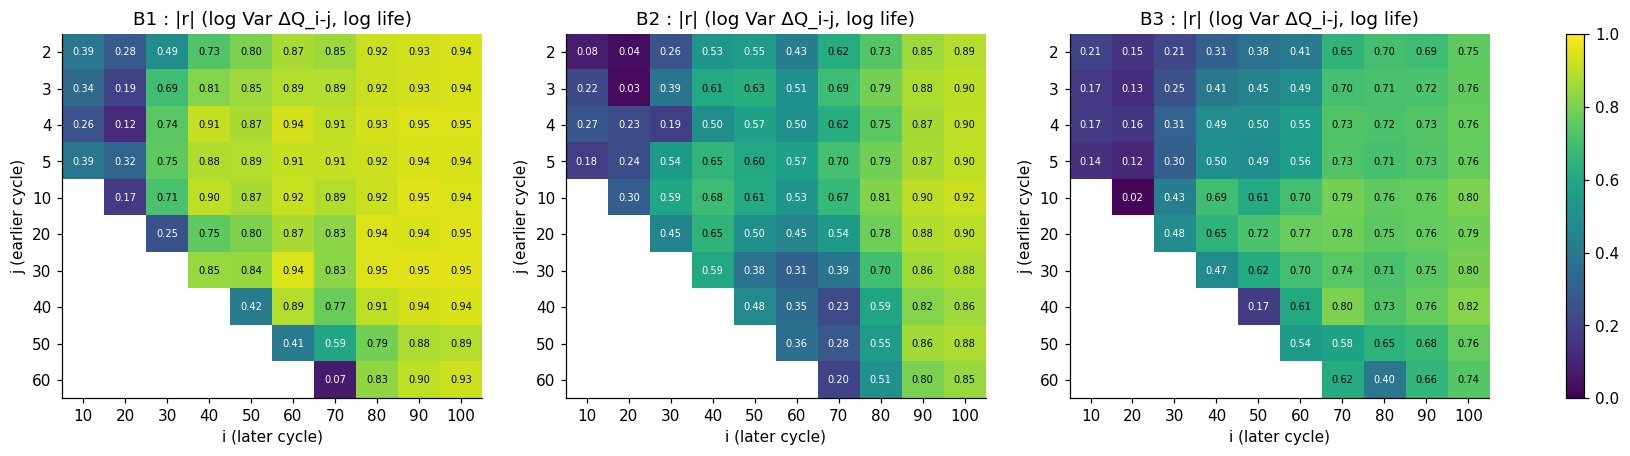


B1 + B2 |r| 합 상위 5개 쌍 : [('100-10', 0.932), ('90-10', 0.925), ('100-4', 0.925), ('100-20', 0.925), ('100-5', 0.922)]
100-10 : {'B1': -0.945, 'B2': -0.918, 'B3': -0.805}


In [ ]:
R.section('2. ΔQ 사이클 쌍 격자 탐색')
I = [c for c in Q_CYCLES if c >= 10]
J = [c for c in Q_CYCLES if c <= 60]
grids = {}
for b in BATCHES:
    cells = meta[meta.batch == b].index
    G = pd.DataFrame(np.nan, index=J, columns=I)
    for i in I:
        for j in J:
            if i <= j:
                continue
            x, y = [], []
            for c in cells:
                v = dq_curve(ds['qdlin'], c, i, j)
                if v is not None:
                    x.append(np.log10(v.var() + 1e-12)); y.append(np.log10(meta.at[c, 'cycle_life']))
            if len(x) > 5:
                G.loc[j, i] = stats.pearsonr(x, y)[0]
    grids[b] = G
    R.table(G, f'{b} : r(log Var ΔQ_i−j, log life)  (행 j, 열 i)', fmt='{:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
for ax, b in zip(axes, BATCHES):
    G = grids[b]
    im = ax.imshow(G.abs().values, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(I))); ax.set_xticklabels(I); ax.set_yticks(range(len(J))); ax.set_yticklabels(J)
    for (jj, ii), v in np.ndenumerate(G.values):
        if not np.isnan(v):
            ax.text(ii, jj, f'{abs(v):.2f}', ha='center', va='center', fontsize=6.5, color='white' if abs(v) < .6 else 'black')
    ax.set(title=f'{b} : |r| (log Var ΔQ_i-j, log life)', xlabel='i (later cycle)', ylabel='j (earlier cycle)')
plt.colorbar(im, ax=axes, fraction=.02); R.savefig('FE_1_dq_cycle_grid')

best = (grids['B1'].abs() + grids['B2'].abs()).stack()
R.log('\nB1 + B2 |r| 합 상위 5개 쌍 :', [(f'{i}-{j}', round(v / 2, 3)) for (j, i), v in best.sort_values(ascending=False).head(5).items()])
R.log('100-10 :', {b: round(float(grids[b].loc[10, 100]), 3) for b in BATCHES})
DQ_PAIR = (100, 10)      # 결과를 보고 바꿀 경우 여기만 수정

## 3. 피처 후보 구성
논문 Supplementary Table 1의 구성을 따른다. 모두 **사이클 100 이내** 데이터만 사용한다.

| 그룹 | 피처 | 연결되는 EDA |
|---|---|---|
| ΔQ(V) (6) | log\|min\|, mean, log var, skew, kurt, 2V 값 | Q3 : 수명 신호의 핵심 |
| 용량 곡선 (7) | 기울기·절편(2–100, 91–100), QD₂, max−QD₂, QD₁₀₀ | Q2 : 단독으로는 약하지만 보완 정보 |
| 기타 (7) | 초기 5사이클 충전시간, Tmax, Tmin, Tavg, IR₂, IR min, IR₁₀₀−IR₂ | Q4 : C-rate → 발열 경로 |
| 정책 (4) | C1, Q1, C2, 평균 C-rate | Q4 : 실험 전에 알 수 있는 조건 |

온도 피처는 논문의 "온도 시간 적분" 대신 사이클 평균 온도(`tavg_2_100`)로 근사했다 (사이클 내부 온도 시계열을 읽지 않았기 때문).

In [ ]:
R.section('3. 피처 테이블')
F = build_feature_table(ds, *DQ_PAIR)
R.log('shape :', F.shape)
miss = F[ALL_FEATS].isna().groupby(F.batch).sum()
R.table(miss.loc[:, miss.sum() > 0] if (miss.sum() > 0).any() else pd.DataFrame({'결측': [0]}), '배치별 결측 수')
susp = ds['meta_raw'].loc[ds['meta_raw'].temp_suspect & ds['meta_raw'].index.isin(F.index)].index.tolist()
R.log('온도 센서 이상 후보 셀 (온도 피처 신뢰도 낮음) :', susp)
R.table(F.groupby('batch')[ALL_FEATS].median().T, '배치별 피처 중앙값')


3. 피처 테이블
shape : (120, 30)

[배치별 결측 수]
       chargetime_5  ir_2  ir_min_2_100  ir_100_minus_2
batch                                                  
B1                1     0             0               0
B2                0     9             6               9
B3                3     2             0               2
온도 센서 이상 후보 셀 (온도 피처 신뢰도 낮음) : ['b1c3', 'b1c31']

[배치별 피처 중앙값]
batch                  B1       B2        B3
dq_log_absmin      -1.429   -1.266    -1.596
dq_mean           -0.0166 -0.02468  -0.01071
dq_log_var         -3.838   -3.487    -4.151
dq_skew           -0.2314 -0.01054   -0.2448
dq_kurt            -1.243   -1.203    -1.154
dq_2V           -0.006138 -0.01126 -0.003618
qd_slope_2_100   -0.05213   0.2198  -0.07423
qd_int_2_100        1.082    1.098     1.068
qd_slope_91_100   -0.3481  0.03537   -0.5175
qd_int_91_100       1.085    1.096     1.072
qd_2                1.078    1.095     1.065
qd_max_minus_2      4.528    6.732     3.151
qd_100              1.081    1.

## 4. 배치 간 안정성
**결정 기준** : B1에서 학습한 관계가 B2·B3에서도 유지되어야 한다.
- **상관 부호 안정성** : 세 배치에서 log life와의 상관 부호가 같은가
- **분포 이동(covariate shift)** : 같은 피처의 값 분포가 배치마다 다른가 (KS 통계량). 분포가 크게 이동한 피처는 B1 범위 밖 값을 B2에서 만나 외삽 오차를 만든다.


4. 배치 간 안정성

[상관(배치별) + 분포 이동(KS D)]
                      B1       B2       B3      ALL  sign_stable  min_abs_r  KS B1-B2  KS B1-B3   p B1-B2
dq_log_var        -0.945  -0.9184  -0.8046  -0.9194         True     0.8046    0.5729    0.5305 1.532e-06
dq_log_absmin    -0.9164  -0.9014  -0.8111  -0.9062         True     0.8111    0.5729    0.5305 1.532e-06
dq_mean           0.8461   0.7907   0.6894    0.845         True     0.6894     0.546    0.5305 5.998e-06
chargetime_5       0.796  -0.9447   0.5933   0.4435        False     0.5933       0.7    0.7669 3.404e-10
avgC             -0.7757   0.3496 -0.02421  -0.4199        False    0.02421    0.7073    0.7073 2.019e-10
dq_2V             0.6978   0.5288    0.486   0.6918         True      0.486    0.5485    0.4372 5.069e-06
dq_skew          -0.6775  -0.1263   -0.291  -0.4807         True     0.1263    0.4703    0.1634 0.0001704
C1               -0.6434   0.1963  0.06952 -0.06647        False    0.06952    0.5228     0.561 1.731e-05
qd_max_m

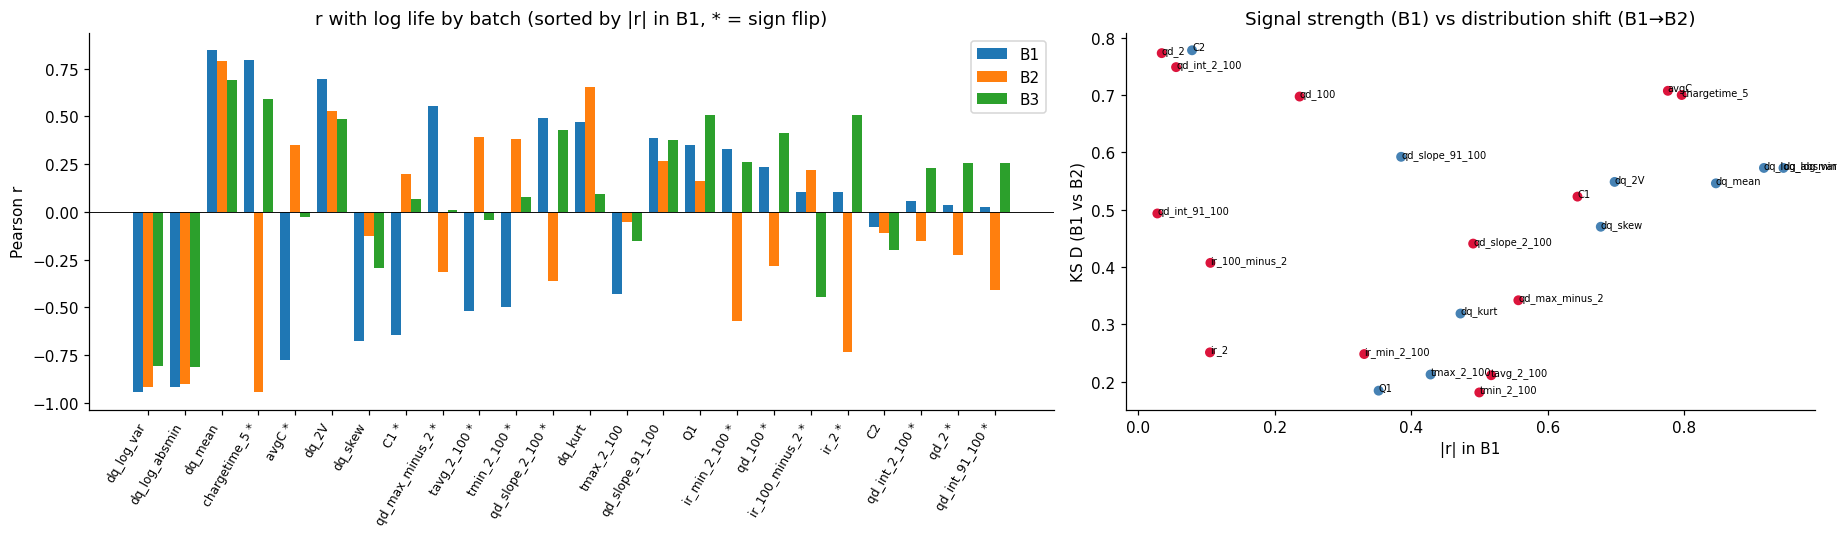

In [ ]:
R.section('4. 배치 간 안정성')
Rb = corr_by_batch(F, ALL_FEATS).sort_values('B1', key=np.abs, ascending=False)
ks = pd.DataFrame({f'KS {a}-{b}': [stats.ks_2samp(F.loc[F.batch == a, f].dropna(), F.loc[F.batch == b, f].dropna()).statistic
                                   for f in ALL_FEATS] for a, b in [('B1', 'B2'), ('B1', 'B3')]}, index=ALL_FEATS)
ks['p B1-B2'] = [stats.ks_2samp(F.loc[F.batch == 'B1', f].dropna(), F.loc[F.batch == 'B2', f].dropna()).pvalue for f in ALL_FEATS]
stab = Rb.join(ks)
R.table(stab, '상관(배치별) + 분포 이동(KS D)')

fig, axes = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [1.4, 1]})
ax = axes[0]
x = np.arange(len(Rb)); w = .27
for k, b in enumerate(BATCHES):
    ax.bar(x + (k - 1) * w, Rb[b], w, color=BCOLOR[b], label=b)
ax.axhline(0, color='k', lw=.6); ax.set_xticks(x)
ax.set_xticklabels([f'{i}{"" if s_ else " *"}' for i, s_ in zip(Rb.index, Rb.sign_stable)], rotation=60, ha='right', fontsize=8)
ax.set(title='r with log life by batch (sorted by |r| in B1, * = sign flip)', ylabel='Pearson r'); ax.legend()
ax = axes[1]
ax.scatter(stab['B1'].abs(), stab['KS B1-B2'], c=['crimson' if not s_ else 'steelblue' for s_ in stab.sign_stable], s=30)
for f, r in stab.iterrows():
    ax.annotate(f, (abs(r['B1']), r['KS B1-B2']), fontsize=6.5)
ax.set(title='Signal strength (B1) vs distribution shift (B1→B2)', xlabel='|r| in B1', ylabel='KS D (B1 vs B2)')
plt.tight_layout(); R.savefig('FE_2_batch_stability')

## 5. 다중공선성 — VIF 전/후 (Batch 1 기준)
VIF가 가장 큰 피처부터 하나씩 제거하고, 모든 피처의 VIF < 10이 될 때까지 반복한다. ΔQ 분산(`dq_log_var`)은 핵심 신호이므로 항상 유지한다.


5. VIF
VIF 계산 제외(결측/상수) : []

[VIF 전/후]
                 VIF_before  VIF_after
qd_int_91_100      6.27e+04        NaN
qd_100            3.062e+04      2.547
qd_slope_91_100   1.629e+04      4.245
qd_int_2_100      1.592e+04        NaN
qd_2                   2710        NaN
qd_slope_2_100         1627        NaN
dq_log_var             1100       13.3
dq_log_absmin         897.3        NaN
avgC                  657.9        NaN
chargetime_5          625.2      9.889
ir_2                  365.5        NaN
ir_100_minus_2        314.2      1.866
tavg_2_100            313.4        NaN
dq_mean               267.4        NaN
dq_2V                 172.5        NaN
tmax_2_100            154.9      2.037
ir_min_2_100            143       3.43
tmin_2_100            48.01      5.763
qd_max_minus_2        46.97      4.468
C1                    37.33        NaN
Q1                    34.05      4.092
dq_skew               33.03      5.534
dq_kurt                21.3      2.839
C2                    7

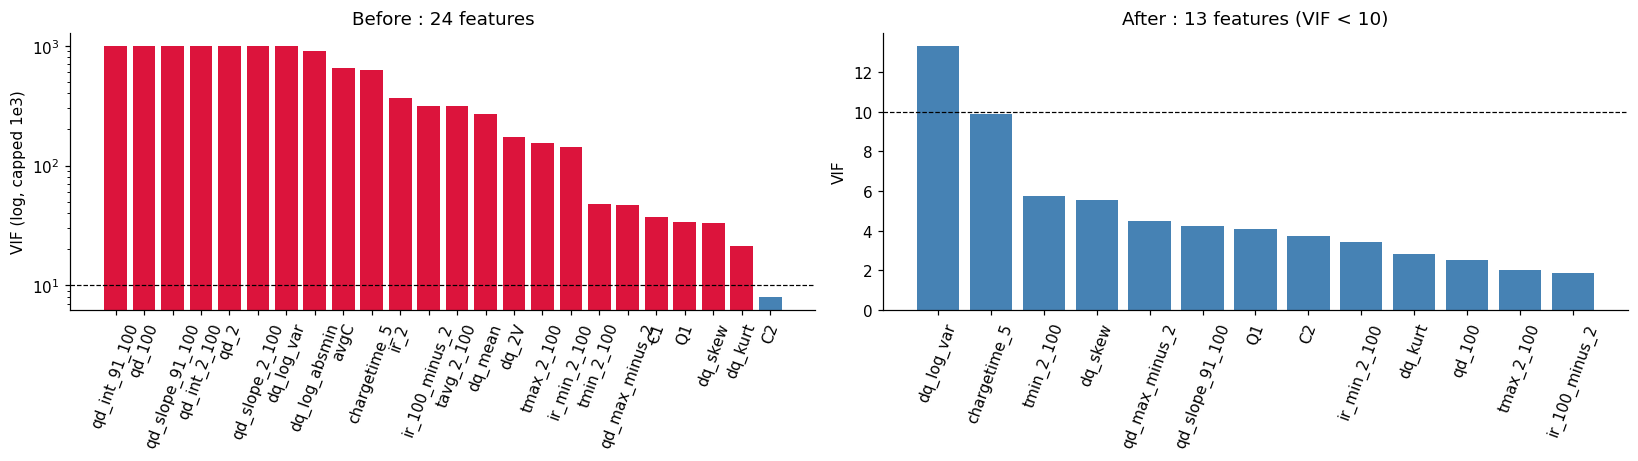

In [ ]:
R.section('5. VIF')
usable = usable_features(F, ALL_FEATS)
R.log('VIF 계산 제외(결측/상수) :', [c for c in ALL_FEATS if c not in usable])
train = F[F.batch == 'B1'][usable].dropna()
v_before = vif(train)
keep_vif = select_by_vif(train)
v_after = vif(train[keep_vif])
R.table(pd.DataFrame({'VIF_before': v_before, 'VIF_after': v_after}).sort_values('VIF_before', ascending=False), 'VIF 전/후')
R.log('남은 피처 :', keep_vif)
R.log('제거된 피처 :', [c for c in usable if c not in keep_vif])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
vb = v_before.sort_values(ascending=False)
axes[0].bar(vb.index, np.minimum(vb.values, 1e3), color=['crimson' if v >= 10 else 'steelblue' for v in vb.values])
axes[0].set_yscale('log'); axes[0].axhline(10, color='k', ls='--', lw=.8); axes[0].tick_params(axis='x', rotation=70)
axes[0].set(title=f'Before : {len(usable)} features', ylabel='VIF (log, capped 1e3)')
va = v_after.sort_values(ascending=False)
axes[1].bar(va.index, va.values, color='steelblue'); axes[1].axhline(10, color='k', ls='--', lw=.8); axes[1].tick_params(axis='x', rotation=70)
axes[1].set(title=f'After : {len(keep_vif)} features (VIF < 10)', ylabel='VIF')
plt.tight_layout(); R.savefig('FE_3_vif_before_after')

## 6. 최종 피처 세트
03_modeling에서 비교할 세트를 저장한다.

- `variance` : ΔQ 분산 1개 (논문 Variance model — 기준선)
- `discharge` : 방전 데이터만 (논문 Discharge model 후보 13개)
- `full` : 20개 전체 (논문 Full model 후보) — Elastic Net이 스스로 선택
- `selected` : VIF < 10 **그리고** 세 배치에서 상관 부호가 같은 피처 (우리 EDA 기반 선택)

정규화 선형모델(Elastic Net)은 중복 피처가 있어도 계수를 줄여 대응하므로 `full`을 그대로 넣고, 트리 모델이나 일반 선형회귀는 `selected`를 쓰는 식으로 03에서 비교한다.

In [ ]:
R.section('6. 최종 피처 세트')
sign_ok = set(Rb.index[Rb.sign_stable])
selected = [f for f in keep_vif if f in sign_ok]
if 'dq_log_var' not in selected:
    selected = ['dq_log_var'] + selected
sets = {k: [f for f in v if f in usable] for k, v in FEATURE_SETS.items()}
sets['selected'] = selected
for k, v in sets.items():
    R.log(f'  {k:12s} ({len(v):2d}) : {v}')

# 피처 신호 확인 : B1에서 맞춘 단일 피처 선형식이 B2·B3에서도 유지되는가 (모델 성능이 아니라 신호 점검용)
tr = F[F.batch == 'B1'].dropna(subset=['dq_log_var'])
p = np.polyfit(tr.dq_log_var, tr.log_life, 1)
for b in BATCHES:
    s = F[F.batch == b].dropna(subset=['dq_log_var'])
    pred = 10 ** np.polyval(p, s.dq_log_var)
    R.log(f'  [variance 단일 피처] {b}: MAPE = {np.mean(np.abs(pred - s.cycle_life) / s.cycle_life) * 100:.1f}%  '
          f'(논문 Variance model : 1차 테스트 14.7%, 2차 11.4%)')

os.makedirs(PROCESSED_DIR, exist_ok=True)
F.to_csv(os.path.join(PROCESSED_DIR, 'features.csv'))
with open(os.path.join(PROCESSED_DIR, 'feature_sets.json'), 'w') as fp:
    json.dump(dict(dq_pair=list(DQ_PAIR), target='log_life', sets=sets), fp, indent=2, ensure_ascii=False)
R.log('저장 :', os.path.join(PROCESSED_DIR, 'features.csv'), '/ feature_sets.json')


6. 최종 피처 세트
  variance     ( 1) : ['dq_log_var']
  discharge    (13) : ['dq_log_absmin', 'dq_mean', 'dq_log_var', 'dq_skew', 'dq_kurt', 'dq_2V', 'qd_slope_2_100', 'qd_int_2_100', 'qd_slope_91_100', 'qd_int_91_100', 'qd_2', 'qd_max_minus_2', 'qd_100']
  full         (20) : ['dq_log_absmin', 'dq_mean', 'dq_log_var', 'dq_skew', 'dq_kurt', 'dq_2V', 'qd_slope_2_100', 'qd_int_2_100', 'qd_slope_91_100', 'qd_int_91_100', 'qd_2', 'qd_max_minus_2', 'qd_100', 'chargetime_5', 'tmax_2_100', 'tmin_2_100', 'tavg_2_100', 'ir_2', 'ir_min_2_100', 'ir_100_minus_2']
  full+policy  (24) : ['dq_log_absmin', 'dq_mean', 'dq_log_var', 'dq_skew', 'dq_kurt', 'dq_2V', 'qd_slope_2_100', 'qd_int_2_100', 'qd_slope_91_100', 'qd_int_91_100', 'qd_2', 'qd_max_minus_2', 'qd_100', 'chargetime_5', 'tmax_2_100', 'tmin_2_100', 'tavg_2_100', 'ir_2', 'ir_min_2_100', 'ir_100_minus_2', 'C1', 'Q1', 'C2', 'avgC']
  selected     ( 7) : ['dq_log_var', 'dq_skew', 'dq_kurt', 'qd_slope_91_100', 'tmax_2_100', 'Q1', 'C2']
  [variance 단일

In [ ]:
R.zip_and_download()

저장 : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/02_feature_engineering.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/02_feature_engineering.zip'